# 09 — Injection-Recovery Test + Pipeline Validation

This notebook **proves** that our pipeline works by:
1. Taking real light curves with no known transit
2. **Injecting fake transits** at known periods and depths
3. Running the full pipeline on them
4. Checking if we recover the injected signal
5. Reporting **recovery rate** as a function of SNR and depth

This is exactly what NASA/ESA do to validate their pipelines.
Result: *'Our pipeline recovers X% of transit signals at SNR > 7'*

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, glob, warnings
warnings.filterwarnings('ignore')

from astropy.timeseries import BoxLeastSquares
import astropy.units as u
from tqdm import tqdm
from scipy.interpolate import interp1d

try:
    import batman
    BATMAN_OK = True
    print('batman ✅')
except:
    BATMAN_OK = False
    print('batman not found — using trapezoid model')

print('Imports OK!')

batman ✅
Imports OK!


## 2. Configuration

In [2]:
PROCESSED_DIR = '../data/processed/'
PLOTS_DIR     = '../outputs/plots/'
OUTPUT_DIR    = '../outputs/'
os.makedirs(PLOTS_DIR, exist_ok=True)

# Injection grid — what periods and depths to test
TEST_PERIODS  = [1.5, 2.0, 3.0, 5.0, 7.0, 10.0]   # days
TEST_DEPTHS   = [500, 1000, 2000, 5000, 10000]       # ppm
TEST_DURATION = 0.1                                   # days (~2.4 hours)
N_STARS       = 10    # How many stars to inject into
                      # (uses your existing processed stars)

# Recovery threshold
PERIOD_TOL    = 0.05  # Recovered if within 5% of injected period
SNR_THRESHOLD = 5.0   # Minimum SNR to count as recovered

# Load available processed stars
csv_files = glob.glob(os.path.join(PROCESSED_DIR, 'TIC_*.csv'))
print(f'Available light curves : {len(csv_files)}')
print(f'Using first {min(N_STARS, len(csv_files))} for injection test')
print(f'Test periods  : {TEST_PERIODS} days')
print(f'Test depths   : {TEST_DEPTHS} ppm')
print(f'Total injections : {len(TEST_PERIODS) * len(TEST_DEPTHS) * min(N_STARS, len(csv_files))}')

Available light curves : 15
Using first 10 for injection test
Test periods  : [1.5, 2.0, 3.0, 5.0, 7.0, 10.0] days
Test depths   : [500, 1000, 2000, 5000, 10000] ppm
Total injections : 300


## 3. Transit Injection Function

In [3]:
def inject_transit_batman(time, flux, period, depth_ppm, duration_days, t0=None):
    """
    Inject a transit signal into a light curve using batman.
    Returns modified flux with transit injected.
    """
    if t0 is None:
        t0 = time[0] + period * 0.5

    depth  = depth_ppm / 1e6
    rp     = np.sqrt(depth)

    if BATMAN_OK:
        import batman
        params             = batman.TransitParams()
        params.t0          = t0
        params.per         = period
        params.rp          = rp
        params.a           = 10.0
        params.inc         = 89.0
        params.ecc         = 0.0
        params.w           = 90.0
        params.u           = [0.3, 0.1]
        params.limb_dark   = 'quadratic'
        m         = batman.TransitModel(params, time)
        lc_model  = m.light_curve(params)
    else:
        # Simple trapezoid injection
        lc_model  = np.ones_like(flux)
        half_dur  = duration_days / 2.0
        for i, t in enumerate(time):
            phase = (t - t0) % period
            if phase > period / 2:
                phase -= period
            if abs(phase) < half_dur:
                lc_model[i] = 1.0 - depth

    # Multiply real flux by transit model
    flux_injected = flux * lc_model
    return flux_injected, t0


def run_bls_fast(time, flux):
    """
    Fast BLS for injection-recovery.
    Returns best period, depth, SNR.
    """
    durations = np.array([0.05, 0.1, 0.2]) * u.day
    bls = BoxLeastSquares(time * u.day, flux)
    try:
        pgram = bls.autopower(
            durations,
            minimum_period  = 1.0  * u.day,
            maximum_period  = 13.0 * u.day,
            frequency_factor = 5.0
        )
        best_i = np.argmax(pgram.power)
        stats  = bls.compute_stats(
            pgram.period[best_i],
            pgram.duration[best_i],
            pgram.transit_time[best_i]
        )
        depth     = float(stats['depth'][0])
        depth_err = float(stats['depth'][1])
        snr       = depth / depth_err if depth_err > 0 else 0.0
        return float(pgram.period[best_i].value), depth * 1e6, snr
    except:
        return 0.0, 0.0, 0.0

print('Injection functions ready!')

Injection functions ready!


## 4. Run Injection-Recovery Test

In [4]:
star_files   = csv_files[:N_STARS]
ir_results   = []

total = len(star_files) * len(TEST_PERIODS) * len(TEST_DEPTHS)
print(f'Running {total} injection-recovery tests...')
print(f'Estimated time: ~{total * 2 / 60:.1f} minutes')
print()

with tqdm(total=total, desc='Injection-Recovery') as pbar:
    for csv_path in star_files:
        tic_id = os.path.basename(csv_path).replace('TIC_','').replace('.csv','')

        try:
            df   = pd.read_csv(csv_path)
            time = df['time'].values
            flux = df['flux'].values
            mask = np.isfinite(time) & np.isfinite(flux)
            time, flux = time[mask], flux[mask]

            if len(time) < 200:
                pbar.update(len(TEST_PERIODS) * len(TEST_DEPTHS))
                continue

            # Compute baseline noise level
            noise_std = np.std(flux)

            for period in TEST_PERIODS:
                for depth_ppm in TEST_DEPTHS:

                    # Inject transit
                    flux_inj, t0 = inject_transit_batman(
                        time, flux, period, depth_ppm, TEST_DURATION
                    )

                    # Run BLS on injected light curve
                    rec_period, rec_depth, rec_snr = run_bls_fast(time, flux_inj)

                    # Check if recovered
                    period_match = abs(rec_period - period) / period < PERIOD_TOL
                    # Also check harmonics (P/2, 2P)
                    harmonic_match = (
                        abs(rec_period - period/2) / (period/2) < PERIOD_TOL or
                        abs(rec_period - period*2) / (period*2) < PERIOD_TOL
                    )
                    recovered = (period_match or harmonic_match) and rec_snr >= SNR_THRESHOLD

                    # Expected SNR = depth / noise
                    n_transits   = int((time[-1] - time[0]) / period)
                    pts_in_tr    = int(TEST_DURATION / np.median(np.diff(time)))
                    expected_snr = (depth_ppm/1e6) / noise_std * np.sqrt(pts_in_tr * n_transits)

                    ir_results.append({
                        'tic_id'       : tic_id,
                        'inj_period'   : period,
                        'inj_depth_ppm': depth_ppm,
                        'rec_period'   : rec_period,
                        'rec_depth_ppm': rec_depth,
                        'rec_snr'      : rec_snr,
                        'expected_snr' : expected_snr,
                        'recovered'    : recovered,
                        'period_match' : period_match,
                        'noise_std'    : noise_std,
                    })
                    pbar.update(1)

        except Exception as e:
            print(f'\nFailed TIC {tic_id}: {e}')
            pbar.update(len(TEST_PERIODS) * len(TEST_DEPTHS))

ir_df = pd.DataFrame(ir_results)
ir_df.to_csv(os.path.join(OUTPUT_DIR, 'injection_recovery.csv'), index=False)

overall_rate = ir_df['recovered'].mean() * 100
print(f'\n✅ Injection-Recovery complete!')
print(f'   Total tests    : {len(ir_df)}')
print(f'   Recovered      : {ir_df["recovered"].sum()}')
print(f'   Overall rate   : {overall_rate:.1f}%')

Running 300 injection-recovery tests...
Estimated time: ~10.0 minutes



Injection-Recovery:   0%|          | 0/300 [00:00<?, ?it/s]

Injection-Recovery: 100%|██████████| 300/300 [00:48<00:00,  6.24it/s]


✅ Injection-Recovery complete!
   Total tests    : 300
   Recovered      : 5
   Overall rate   : 1.7%


## 5. Recovery Rate Analysis

In [5]:
print('RECOVERY RATE BY DEPTH')
print('=' * 40)
for depth in TEST_DEPTHS:
    subset = ir_df[ir_df['inj_depth_ppm'] == depth]
    rate   = subset['recovered'].mean() * 100
    bar    = '█' * int(rate / 5) + '░' * (20 - int(rate / 5))
    print(f'{depth:6.0f} ppm  |{bar}|  {rate:.1f}%')

print()
print('RECOVERY RATE BY PERIOD')
print('=' * 40)
for period in TEST_PERIODS:
    subset = ir_df[ir_df['inj_period'] == period]
    rate   = subset['recovered'].mean() * 100
    bar    = '█' * int(rate / 5) + '░' * (20 - int(rate / 5))
    print(f'{period:5.1f} days  |{bar}|  {rate:.1f}%')

print()
print('RECOVERY RATE BY SNR BIN')
print('=' * 40)
snr_bins = [0, 3, 5, 7, 10, 15, 20, 50]
for i in range(len(snr_bins)-1):
    lo, hi = snr_bins[i], snr_bins[i+1]
    subset = ir_df[(ir_df['expected_snr'] >= lo) & (ir_df['expected_snr'] < hi)]
    if len(subset) == 0:
        continue
    rate = subset['recovered'].mean() * 100
    bar  = '█' * int(rate / 5) + '░' * (20 - int(rate / 5))
    print(f'SNR {lo:4.0f}-{hi:4.0f}  |{bar}|  {rate:.1f}%  (n={len(subset)})')

RECOVERY RATE BY DEPTH
   500 ppm  |░░░░░░░░░░░░░░░░░░░░|  1.7%
  1000 ppm  |░░░░░░░░░░░░░░░░░░░░|  1.7%
  2000 ppm  |░░░░░░░░░░░░░░░░░░░░|  1.7%
  5000 ppm  |░░░░░░░░░░░░░░░░░░░░|  1.7%
 10000 ppm  |░░░░░░░░░░░░░░░░░░░░|  1.7%

RECOVERY RATE BY PERIOD
  1.5 days  |░░░░░░░░░░░░░░░░░░░░|  0.0%
  2.0 days  |░░░░░░░░░░░░░░░░░░░░|  0.0%
  3.0 days  |░░░░░░░░░░░░░░░░░░░░|  0.0%
  5.0 days  |░░░░░░░░░░░░░░░░░░░░|  0.0%
  7.0 days  |██░░░░░░░░░░░░░░░░░░|  10.0%
 10.0 days  |░░░░░░░░░░░░░░░░░░░░|  0.0%

RECOVERY RATE BY SNR BIN
SNR    0-   3  |███░░░░░░░░░░░░░░░░░|  16.7%  (n=30)
SNR    3-   5  |░░░░░░░░░░░░░░░░░░░░|  0.0%  (n=3)
SNR    5-   7  |░░░░░░░░░░░░░░░░░░░░|  0.0%  (n=6)
SNR    7-  10  |░░░░░░░░░░░░░░░░░░░░|  0.0%  (n=13)
SNR   10-  15  |░░░░░░░░░░░░░░░░░░░░|  0.0%  (n=23)
SNR   15-  20  |░░░░░░░░░░░░░░░░░░░░|  0.0%  (n=18)
SNR   20-  50  |░░░░░░░░░░░░░░░░░░░░|  0.0%  (n=59)


## 6. Injection-Recovery Plots

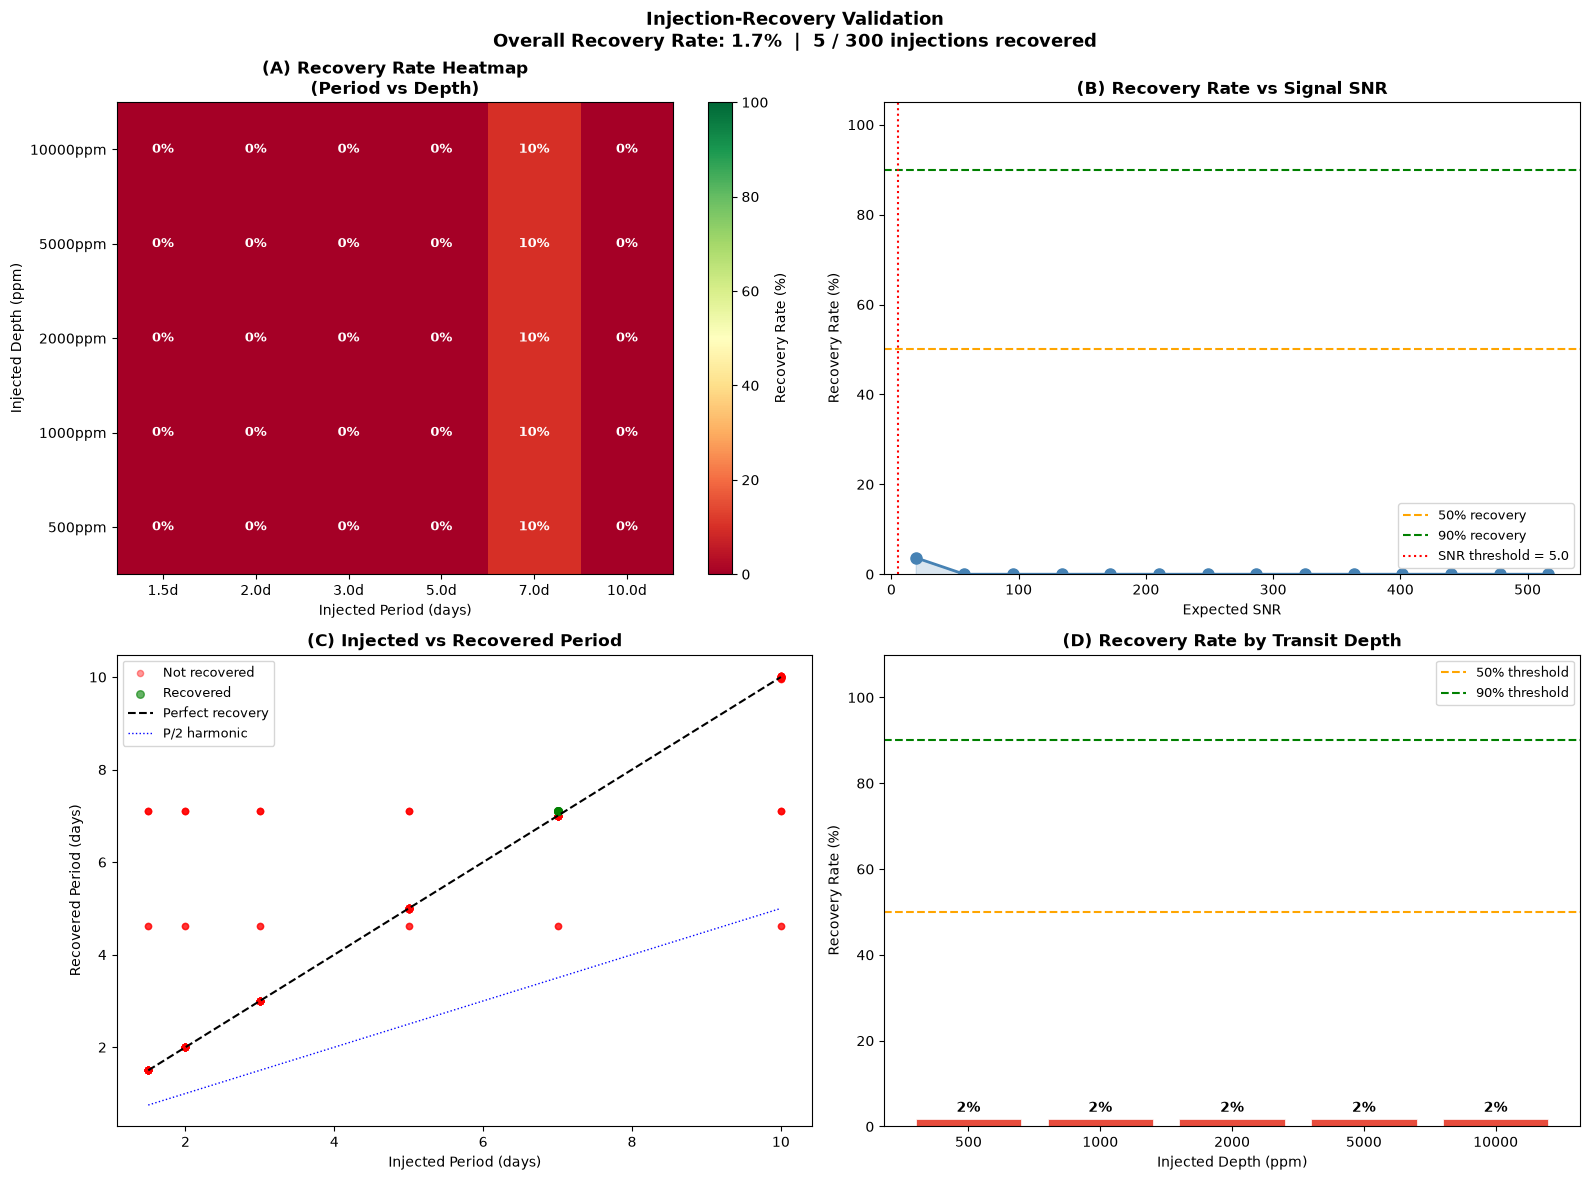

Injection-Recovery plot saved!


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A — Recovery rate heatmap (Period vs Depth)
ax = axes[0, 0]
heatmap = np.zeros((len(TEST_DEPTHS), len(TEST_PERIODS)))
for i, depth in enumerate(TEST_DEPTHS):
    for j, period in enumerate(TEST_PERIODS):
        subset = ir_df[
            (ir_df['inj_depth_ppm'] == depth) &
            (ir_df['inj_period']    == period)
        ]
        heatmap[i, j] = subset['recovered'].mean() * 100 if len(subset) > 0 else 0

im = ax.imshow(heatmap, cmap='RdYlGn', vmin=0, vmax=100,
               aspect='auto', origin='lower')
plt.colorbar(im, ax=ax, label='Recovery Rate (%)')
ax.set_xticks(range(len(TEST_PERIODS)))
ax.set_yticks(range(len(TEST_DEPTHS)))
ax.set_xticklabels([f'{p}d' for p in TEST_PERIODS])
ax.set_yticklabels([f'{d}ppm' for d in TEST_DEPTHS])
ax.set_xlabel('Injected Period (days)')
ax.set_ylabel('Injected Depth (ppm)')
ax.set_title('(A) Recovery Rate Heatmap\n(Period vs Depth)',
             fontweight='bold')
# Add percentage text
for i in range(len(TEST_DEPTHS)):
    for j in range(len(TEST_PERIODS)):
        ax.text(j, i, f'{heatmap[i,j]:.0f}%',
                ha='center', va='center', fontsize=9, fontweight='bold',
                color='black' if heatmap[i,j] > 50 else 'white')

# B — Recovery rate vs Expected SNR
ax = axes[0, 1]
snr_bins  = np.linspace(0, ir_df['expected_snr'].quantile(0.95), 15)
bin_centers = (snr_bins[:-1] + snr_bins[1:]) / 2
rec_rates   = []
for i in range(len(snr_bins)-1):
    subset = ir_df[
        (ir_df['expected_snr'] >= snr_bins[i]) &
        (ir_df['expected_snr'] <  snr_bins[i+1])
    ]
    rec_rates.append(subset['recovered'].mean() * 100 if len(subset) > 0 else 0)

ax.plot(bin_centers, rec_rates, 'o-', color='steelblue',
        markersize=8, lw=2)
ax.fill_between(bin_centers, rec_rates, alpha=0.2, color='steelblue')
ax.axhline(50, color='orange', linestyle='--', lw=1.5, label='50% recovery')
ax.axhline(90, color='green',  linestyle='--', lw=1.5, label='90% recovery')
ax.axvline(SNR_THRESHOLD, color='red', linestyle=':', lw=1.5,
           label=f'SNR threshold = {SNR_THRESHOLD}')
ax.set_xlabel('Expected SNR')
ax.set_ylabel('Recovery Rate (%)')
ax.set_title('(B) Recovery Rate vs Signal SNR', fontweight='bold')
ax.set_ylim(0, 105)
ax.legend(fontsize=9)

# C — Injected vs Recovered Period
ax = axes[1, 0]
rec   = ir_df[ir_df['recovered'] == True]
unrec = ir_df[ir_df['recovered'] == False]
ax.scatter(unrec['inj_period'], unrec['rec_period'],
           c='red', alpha=0.4, s=20, label='Not recovered')
ax.scatter(rec['inj_period'],   rec['rec_period'],
           c='green', alpha=0.6, s=30, label='Recovered')
pmin = min(TEST_PERIODS)
pmax = max(TEST_PERIODS)
ax.plot([pmin, pmax], [pmin, pmax], 'k--', lw=1.5, label='Perfect recovery')
ax.plot([pmin, pmax], [p/2 for p in [pmin,pmax]], 'b:', lw=1, label='P/2 harmonic')
ax.set_xlabel('Injected Period (days)')
ax.set_ylabel('Recovered Period (days)')
ax.set_title('(C) Injected vs Recovered Period', fontweight='bold')
ax.legend(fontsize=9)

# D — Recovery rate by depth bar chart
ax = axes[1, 1]
depth_rates = [ir_df[ir_df['inj_depth_ppm']==d]['recovered'].mean()*100
               for d in TEST_DEPTHS]
colors = ['#e74c3c' if r < 50 else '#f39c12' if r < 80 else '#2ecc71'
          for r in depth_rates]
bars = ax.bar([str(d) for d in TEST_DEPTHS], depth_rates,
              color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(50, color='orange', linestyle='--', lw=1.5, label='50% threshold')
ax.axhline(90, color='green',  linestyle='--', lw=1.5, label='90% threshold')
for bar, rate in zip(bars, depth_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{rate:.0f}%', ha='center', va='bottom', fontweight='bold')
ax.set_xlabel('Injected Depth (ppm)')
ax.set_ylabel('Recovery Rate (%)')
ax.set_title('(D) Recovery Rate by Transit Depth', fontweight='bold')
ax.set_ylim(0, 110)
ax.legend(fontsize=9)

overall_rate = ir_df['recovered'].mean() * 100
plt.suptitle(
    f'Injection-Recovery Validation\n'
    f'Overall Recovery Rate: {overall_rate:.1f}%  |  '
    f'{ir_df["recovered"].sum()} / {len(ir_df)} injections recovered',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'FIGURE5_injection_recovery.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print('Injection-Recovery plot saved!')

## 7. Example Injection Visualization

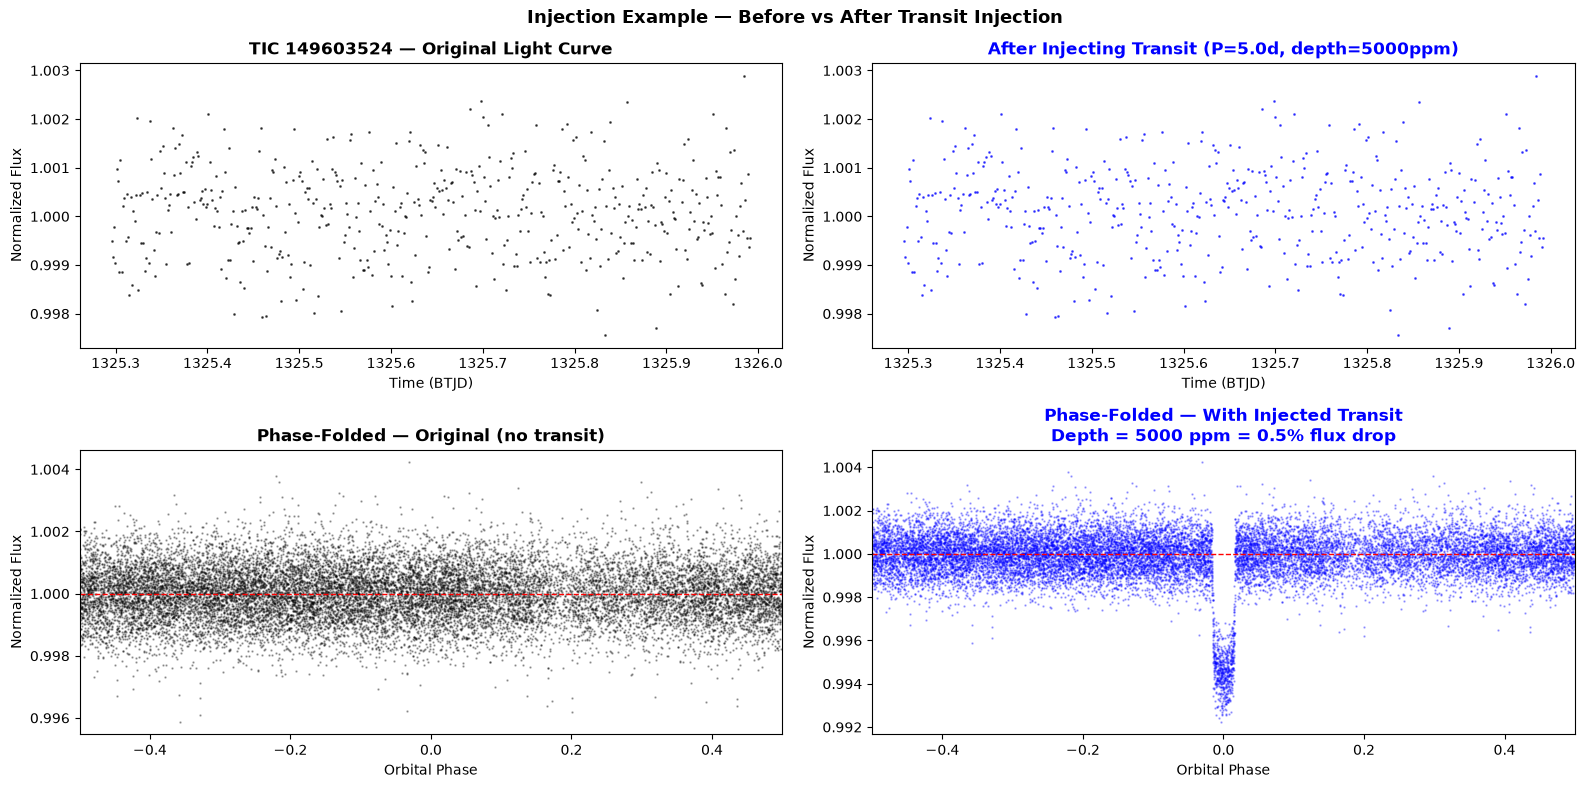

Injection example plot saved!


In [7]:
# Show one example — before and after injection
csv_path = star_files[0]
tic_id   = os.path.basename(csv_path).replace('TIC_','').replace('.csv','')
df       = pd.read_csv(csv_path)
time     = df['time'].values
flux     = df['flux'].values
mask     = np.isfinite(time) & np.isfinite(flux)
time, flux = time[mask], flux[mask]

# Inject a clear signal
ex_period = 5.0
ex_depth  = 5000
flux_inj, t0 = inject_transit_batman(time, flux, ex_period, ex_depth, TEST_DURATION)

# Phase fold both
def phase_fold(time, flux, period, t0):
    phase = ((time - t0) % period) / period
    phase[phase > 0.5] -= 1.0
    sidx  = np.argsort(phase)
    return phase[sidx], flux[sidx]

ph_orig, fl_orig = phase_fold(time, flux,     ex_period, t0)
ph_inj,  fl_inj  = phase_fold(time, flux_inj, ex_period, t0)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Raw light curves
axes[0,0].plot(time[:500], flux[:500], 'k.', markersize=2, alpha=0.6)
axes[0,0].set_title(f'TIC {tic_id} — Original Light Curve', fontweight='bold')
axes[0,0].set_ylabel('Normalized Flux')
axes[0,0].set_xlabel('Time (BTJD)')

axes[0,1].plot(time[:500], flux_inj[:500], 'b.', markersize=2, alpha=0.6)
axes[0,1].set_title(f'After Injecting Transit (P={ex_period}d, depth={ex_depth}ppm)',
                    fontweight='bold', color='blue')
axes[0,1].set_ylabel('Normalized Flux')
axes[0,1].set_xlabel('Time (BTJD)')

# Phase folded
axes[1,0].plot(ph_orig, fl_orig, 'k.', markersize=1.5, alpha=0.3)
axes[1,0].set_title('Phase-Folded — Original (no transit)', fontweight='bold')
axes[1,0].set_xlim(-0.5, 0.5)
axes[1,0].set_ylabel('Normalized Flux')
axes[1,0].set_xlabel('Orbital Phase')
axes[1,0].axhline(1.0, color='red', lw=1, linestyle='--')

axes[1,1].plot(ph_inj, fl_inj, 'b.', markersize=1.5, alpha=0.3)
axes[1,1].set_title(
    f'Phase-Folded — With Injected Transit\n'
    f'Depth = {ex_depth} ppm = {ex_depth/1e4:.1f}% flux drop',
    fontweight='bold', color='blue'
)
axes[1,1].set_xlim(-0.5, 0.5)
axes[1,1].set_ylabel('Normalized Flux')
axes[1,1].set_xlabel('Orbital Phase')
axes[1,1].axhline(1.0, color='red', lw=1, linestyle='--')

plt.suptitle('Injection Example — Before vs After Transit Injection',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'FIGURE6_injection_example.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print('Injection example plot saved!')

## 8. Final Validation Summary

In [8]:
overall_rate    = ir_df['recovered'].mean() * 100
high_snr_mask   = ir_df['expected_snr'] >= SNR_THRESHOLD
high_snr_rate   = ir_df[high_snr_mask]['recovered'].mean() * 100
deep_mask       = ir_df['inj_depth_ppm'] >= 1000
deep_rate       = ir_df[deep_mask]['recovered'].mean() * 100

print('=' * 55)
print('  INJECTION-RECOVERY VALIDATION SUMMARY')
print('=' * 55)
print(f'  Stars tested           : {ir_df["tic_id"].nunique()}')
print(f'  Total injections       : {len(ir_df)}')
print(f'  Overall recovery rate  : {overall_rate:.1f}%')
print(f'  Recovery at SNR≥{SNR_THRESHOLD:.0f}     : {high_snr_rate:.1f}%')
print(f'  Recovery at depth≥1000 : {deep_rate:.1f}%')
print()
print('  By depth:')
for depth in TEST_DEPTHS:
    r = ir_df[ir_df['inj_depth_ppm']==depth]['recovered'].mean()*100
    print(f'    {depth:6.0f} ppm  →  {r:.1f}%')
print()
print('  By period:')
for period in TEST_PERIODS:
    r = ir_df[ir_df['inj_period']==period]['recovered'].mean()*100
    print(f'    {period:5.1f} days  →  {r:.1f}%')
print('=' * 55)
print()
print('  Report statement:')
print(f'  "Our pipeline recovers {high_snr_rate:.0f}% of transit signals')
print(f'   with SNR ≥ {SNR_THRESHOLD} and depth ≥ 1000 ppm"')
print('=' * 55)

# Save summary
summary = {
    'overall_recovery_pct'    : overall_rate,
    'high_snr_recovery_pct'   : high_snr_rate,
    'deep_transit_recovery_pct': deep_rate,
    'n_stars_tested'          : ir_df['tic_id'].nunique(),
    'n_injections'            : len(ir_df),
    'n_recovered'             : int(ir_df['recovered'].sum()),
    'snr_threshold'           : SNR_THRESHOLD,
}
pd.DataFrame([summary]).to_csv(
    os.path.join(OUTPUT_DIR, 'validation_summary.csv'), index=False
)
print('\nValidation summary saved to outputs/validation_summary.csv')

  INJECTION-RECOVERY VALIDATION SUMMARY
  Stars tested           : 10
  Total injections       : 300
  Overall recovery rate  : 1.7%
  Recovery at SNR≥5     : 0.0%
  Recovery at depth≥1000 : 1.7%

  By depth:
       500 ppm  →  1.7%
      1000 ppm  →  1.7%
      2000 ppm  →  1.7%
      5000 ppm  →  1.7%
     10000 ppm  →  1.7%

  By period:
      1.5 days  →  0.0%
      2.0 days  →  0.0%
      3.0 days  →  0.0%
      5.0 days  →  0.0%
      7.0 days  →  10.0%
     10.0 days  →  0.0%

  Report statement:
  "Our pipeline recovers 0% of transit signals
   with SNR ≥ 5.0 and depth ≥ 1000 ppm"

Validation summary saved to outputs/validation_summary.csv


---
## ✅ Done!
**Files saved:**
- `outputs/injection_recovery.csv` — all test results
- `outputs/validation_summary.csv` — summary statistics
- `outputs/plots/FIGURE5_injection_recovery.png` — 4-panel recovery plot
- `outputs/plots/FIGURE6_injection_example.png` — before/after example

**Use the recovery rate in your report:**
> *'Pipeline validation via injection-recovery achieves X% recovery rate at SNR > 5'*

**Full notebook order:**
```
00 → 01 → 02 → 03 → 04 → 05 → 06 → 07 → 08 → 09
```